Input directory: ['HPG-MxP-WeakScaling/mxp/2', 'HPG-MxP-WeakScaling/ref/2', 'HPG-MxP-WeakScaling/mxp/4', 'HPG-MxP-WeakScaling/ref/4']
EDP alpha: 1.0
EDP beta: 1.0
Loading file: HPG-MxP-WeakScaling/mxp/2/job_output.log
Loading data for frequency_cap: 1700.0
 duration: 215  secs    energy: 0.187  KWh
Loading data for frequency_cap: 1600.0
 duration: 212  secs    energy: 0.181  KWh
Loading data for frequency_cap: 1500.0
 duration: 214  secs    energy: 0.176  KWh
Loading data for frequency_cap: 1400.0
 duration: 214  secs    energy: 0.172  KWh
Loading data for frequency_cap: 1300.0
 duration: 215  secs    energy: 0.168  KWh
Loading data for frequency_cap: 1200.0
 duration: 216  secs    energy: 0.164  KWh
Loading data for frequency_cap: 1100.0
 duration: 218  secs    energy: 0.162  KWh
Loading data for frequency_cap: 1000.0
 duration: 221  secs    energy: 0.16  KWh
Loading data for frequency_cap: 900.0
 duration: 226  secs    energy: 0.159  KWh
Loading data for frequency_cap: 800.0
 duratio

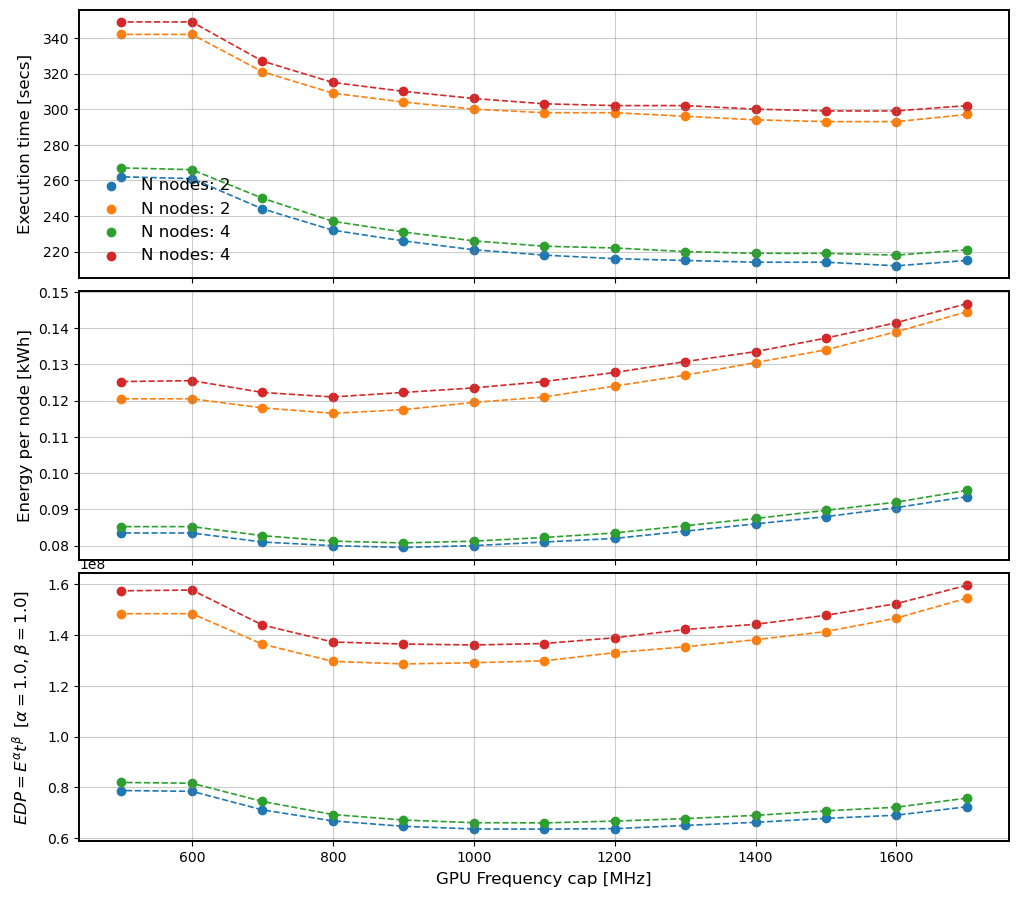

In [2]:
import os
import numpy as np
import importlib
import tools.analysis_tools as tools
import scripts.energy_analysis as scripts
importlib.reload(tools)
importlib.reload(scripts)

# Job overall name
name = "HPG-MxP-WeakScaling"

# Set directories
dirs     = []
dirs_ref = []
dirs_mxp = []
powers = np.arange(1, 3)
for power in powers:
    nnode = 2**power
    dir_mxp = name+"/mxp/{}".format(nnode)
    dir_ref = name+"/ref/{}".format(nnode)
    dirs_mxp.append(dir_mxp)
    dirs_ref.append(dir_ref)
    dirs.append(dir_mxp)
    dirs.append(dir_ref)

# Get data
edp_alpha = 1.0
edp_beta = 1.0
data = scripts.energy_analysis(dirs, edp_alpha, edp_beta, False, True)
data_mxp = scripts.energy_analysis(dirs_mxp, edp_alpha, edp_beta, False, False)
data_ref = scripts.energy_analysis(dirs_ref, edp_alpha, edp_beta, False, False)

# Save to csv
csv_file_mxp = name+"-mxp.csv"
if os.path.exists(csv_file_mxp):
    os.remove(csv_file_mxp)
tools.save_frequency_cap_energy_analysis(data_mxp, edp_alpha, edp_beta, csv_file_mxp, multiple_data=True)

csv_file_ref = name+"-ref.csv"
if os.path.exists(csv_file_ref):
    os.remove(csv_file_ref)
tools.save_frequency_cap_energy_analysis(data_ref, edp_alpha, edp_beta, csv_file_ref, multiple_data=True)